# 02 — Tests de estacionariedad (CPI Global)

Determinacion formal del orden de integracion de `cpi_global_rate`.

**Diferencia respecto a España:** la serie ya es una tasa interanual (YoY %),
no un indice en nivel. Es razonable esperar que sea I(0) o borderline I(1)
dependiendo del periodo, especialmente con los regimenes de shock (2008, 2022).

**Tests aplicados:**
- **ADF** (Augmented Dickey-Fuller) — H0: raiz unitaria
- **KPSS** — H0: estacionaria
- **Phillips-Perron** — H0: raiz unitaria (robusto a heterocedasticidad)

Se aplican sobre: nivel, primera diferencia, diferencia estacional (lag 12).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

NOTEBOOK_DIR = Path("C:/Users/usuario/OneDrive/Documentos/GitHub/tfg-ipc-mcp/tfg-forecasting/02_eda")
ROOT = NOTEBOOK_DIR.parent
MONOREPO = ROOT.parent
sys.path.insert(0, str(MONOREPO))

from shared.constants import DATE_TRAIN_END

plt.rcParams.update({"figure.figsize": (14, 4), "axes.grid": True, "grid.alpha": 0.3})


In [2]:
df = pd.read_parquet(ROOT / "data" / "processed" / "cpi_global_monthly.parquet")
train = df.loc[:DATE_TRAIN_END]
y = train["cpi_global_rate"]
print(f"Train: {y.index.min().date()} -> {y.index.max().date()} ({len(y)} obs)")
print(f"Media: {y.mean():.4f}  Std: {y.std():.4f}  Min: {y.min():.4f}  Max: {y.max():.4f}")


Train: 2002-01-01 -> 2020-12-01 (228 obs)
Media: 3.1553  Std: 1.6185  Min: 0.7993  Max: 9.6395


## 1. Funciones auxiliares

In [3]:
def run_adf(series, name=""):
    result = adfuller(series.dropna(), autolag="AIC")
    stat, pval, lags, nobs = result[0], result[1], result[2], result[3]
    cv = result[4]
    reject = pval < 0.05
    return {
        "test": "ADF", "serie": name,
        "statistic": round(stat, 4), "p_value": round(pval, 4),
        "lags": lags, "nobs": nobs,
        "cv_1%": round(cv["1%"], 4), "cv_5%": round(cv["5%"], 4),
        "reject_H0": reject,
        "conclusion": "Estacionaria" if reject else "No estacionaria",
    }

def run_kpss(series, name="", regression="c"):
    stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
    reject = pval < 0.05
    return {
        "test": f"KPSS({regression})", "serie": name,
        "statistic": round(stat, 4), "p_value": round(pval, 4),
        "lags": lags,
        "cv_5%": round(cv["5%"], 4),
        "reject_H0": reject,
        "conclusion": "No estacionaria" if reject else "Estacionaria",
    }

def run_pp(series, name=""):
    pp = PhillipsPerron(series.dropna())
    reject = pp.pvalue < 0.05
    return {
        "test": "Phillips-Perron", "serie": name,
        "statistic": round(pp.stat, 4), "p_value": round(pp.pvalue, 4),
        "lags": pp.lags,
        "reject_H0": reject,
        "conclusion": "Estacionaria" if reject else "No estacionaria",
    }

def battery(series, name):
    return [
        run_adf(series, name),
        run_kpss(series, name, regression="c"),
        run_kpss(series, name, regression="ct"),
        run_pp(series, name),
    ]


## 2. Tests sobre la serie en nivel (tasa YoY)

In [4]:
results = battery(y, "CPI global nivel")
df_nivel = pd.DataFrame(results)
df_nivel


,test,serie,statistic,p_value,lags,nobs,cv_1%,cv_5%,reject_H0,conclusion
0,ADF,CPI global nivel,-3.4221,0.0102,3,224.0,-3.4599,-2.8745,True,Estacionaria
1,KPSS(c),CPI global nivel,0.5990,0.0227,9,NaN,NaN,0.4630,True,No estacionaria
2,KPSS(ct),CPI global nivel,0.1990,0.0164,9,NaN,NaN,0.1460,True,No estacionaria
3,Phillips-Perron,CPI global nivel,-2.3861,0.1457,15,NaN,NaN,NaN,False,No estacionaria


## 3. Primera diferencia de la tasa (d=1)

Si la tasa YoY en nivel ya fuera I(0) (estacionaria), no necesitariamos
diferenciar. Si es I(1), la primera diferencia de la tasa sera la serie
de trabajo para modelos ARIMA.


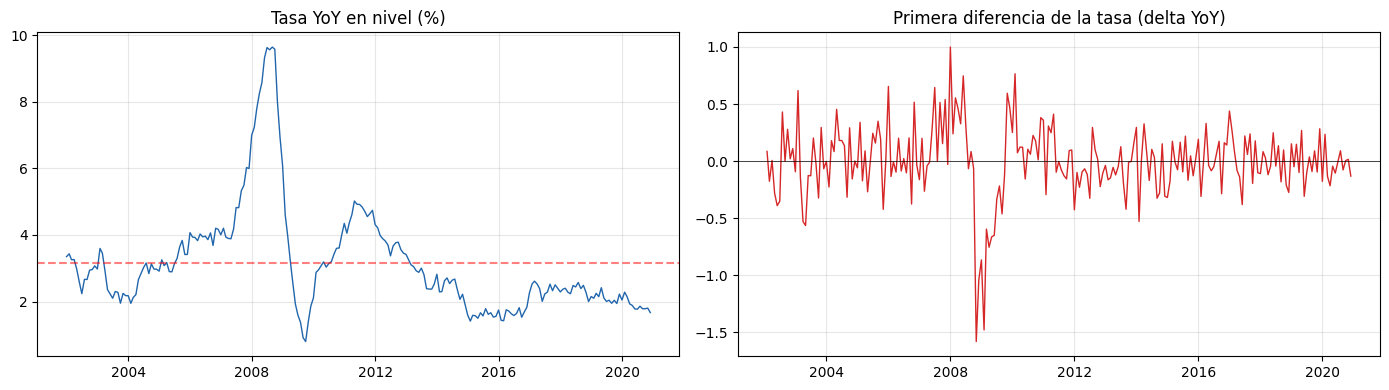

In [5]:
y_diff1 = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y.index, y, linewidth=1, color="#2166ac")
axes[0].set_title("Tasa YoY en nivel (%)")
axes[0].axhline(y.mean(), color="red", linestyle="--", alpha=0.5)

axes[1].plot(y_diff1.index, y_diff1, linewidth=1, color="#d62728")
axes[1].set_title("Primera diferencia de la tasa (delta YoY)")
axes[1].axhline(0, color="black", linewidth=0.5)

for ax in axes:
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


In [6]:
results += battery(y_diff1, "CPI global diff(1)")
df_diff1 = pd.DataFrame(battery(y_diff1, "CPI global diff(1)"))
df_diff1


C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\i

,test,serie,statistic,p_value,lags,nobs,cv_1%,cv_5%,reject_H0,conclusion
0,ADF,CPI global diff(1),-5.6975,0.0,11,215.0,-3.4611,-2.8751,True,Estacionaria
1,KPSS(c),CPI global diff(1),0.0390,0.1,8,NaN,NaN,0.4630,False,Estacionaria
2,KPSS(ct),CPI global diff(1),0.0294,0.1,8,NaN,NaN,0.1460,False,Estacionaria
3,Phillips-Perron,CPI global diff(1),-10.8146,0.0,15,NaN,NaN,NaN,True,Estacionaria


## 4. Diferencia estacional (lag 12)

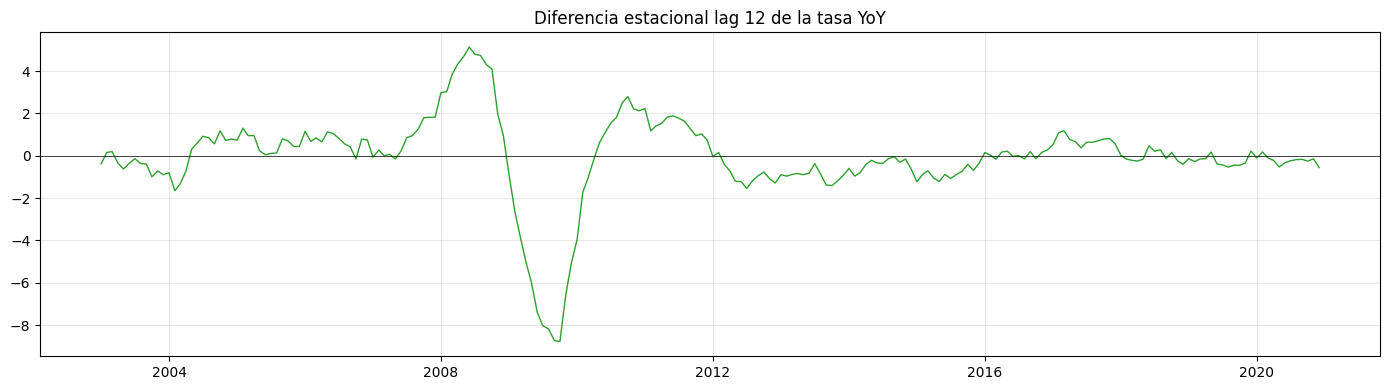

In [7]:
y_diff12 = y.diff(12).dropna()

import matplotlib.dates as mdates
fig, ax = plt.subplots()
ax.plot(y_diff12.index, y_diff12, linewidth=1, color="#2ca02c")
ax.set_title("Diferencia estacional lag 12 de la tasa YoY")
ax.axhline(0, color="black", linewidth=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


In [8]:
results += battery(y_diff12, "CPI global diff(12)")
df_diff12 = pd.DataFrame(battery(y_diff12, "CPI global diff(12)"))
df_diff12


C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\i

,test,serie,statistic,p_value,lags,nobs,cv_1%,cv_5%,reject_H0,conclusion
0,ADF,CPI global diff(12),-4.4719,0.0002,15,200.0,-3.4635,-2.8761,True,Estacionaria
1,KPSS(c),CPI global diff(12),0.0603,0.1000,9,NaN,NaN,0.4630,False,Estacionaria
2,KPSS(ct),CPI global diff(12),0.0396,0.1000,9,NaN,NaN,0.1460,False,Estacionaria
3,Phillips-Perron,CPI global diff(12),-3.2076,0.0195,15,NaN,NaN,NaN,True,Estacionaria


## 5. Doble diferencia: d=1 + D=1

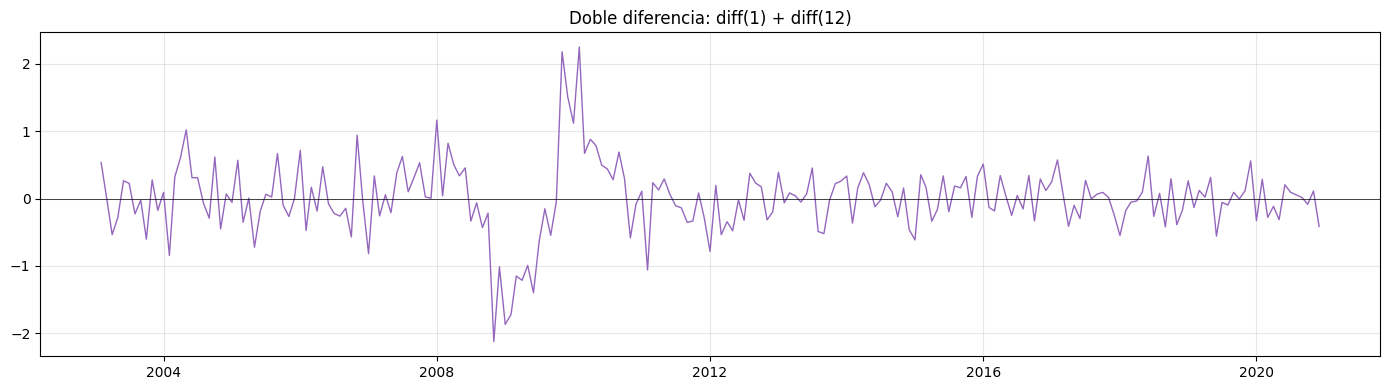

In [9]:
y_diff1_12 = y.diff().diff(12).dropna()

import matplotlib.dates as mdates
fig, ax = plt.subplots()
ax.plot(y_diff1_12.index, y_diff1_12, linewidth=1, color="#9467bd")
ax.set_title("Doble diferencia: diff(1) + diff(12)")
ax.axhline(0, color="black", linewidth=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


In [10]:
results += battery(y_diff1_12, "CPI global diff(1)+diff(12)")
df_double = pd.DataFrame(battery(y_diff1_12, "CPI global diff(1)+diff(12)"))
df_double


C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\1954320303.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\i

,test,serie,statistic,p_value,lags,nobs,cv_1%,cv_5%,reject_H0,conclusion
0,ADF,CPI global diff(1)+diff(12),-4.5174,0.0002,13,201.0,-3.4633,-2.876,True,Estacionaria
1,KPSS(c),CPI global diff(1)+diff(12),0.0205,0.1000,8,NaN,NaN,0.463,False,Estacionaria
2,KPSS(ct),CPI global diff(1)+diff(12),0.0201,0.1000,8,NaN,NaN,0.146,False,Estacionaria
3,Phillips-Perron,CPI global diff(1)+diff(12),-9.5174,0.0000,15,NaN,NaN,NaN,True,Estacionaria


## 6. Tabla resumen

In [11]:
summary = pd.DataFrame(results)
cols_show = ["test", "serie", "statistic", "p_value", "conclusion"]
summary[cols_show].style.applymap(
    lambda v: "background-color: #d4edda" if v == "Estacionaria" else
              "background-color: #f8d7da" if v == "No estacionaria" else "",
    subset=["conclusion"]
)


C:\Users\usuario\AppData\Local\Temp\ipykernel_24816\775756273.py:3: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  summary[cols_show].style.applymap(


,test,serie,statistic,p_value,conclusion
0,ADF,CPI global nivel,-3.422100,0.010200,Estacionaria
1,KPSS(c),CPI global nivel,0.599000,0.022700,No estacionaria
2,KPSS(ct),CPI global nivel,0.199000,0.016400,No estacionaria
3,Phillips-Perron,CPI global nivel,-2.386100,0.145700,No estacionaria
4,ADF,CPI global diff(1),-5.697500,0.000000,Estacionaria
5,KPSS(c),CPI global diff(1),0.039000,0.100000,Estacionaria
6,KPSS(ct),CPI global diff(1),0.029400,0.100000,Estacionaria
7,Phillips-Perron,CPI global diff(1),-10.814600,0.000000,Estacionaria
8,ADF,CPI global diff(12),-4.471900,0.000200,Estacionaria
9,KPSS(c),CPI global diff(12),0.060300,0.100000,Estacionaria


## 7. Conclusion

**Interpretacion conjunta ADF + KPSS + PP:**

| Transformacion | ADF | KPSS | PP | Decision |
|---|---|---|---|---|
| Nivel (YoY %) | Ver celdas | Ver celdas | Ver celdas | I(0) o I(1) segun resultados |
| diff(1) | Ver celdas | Ver celdas | Ver celdas | Confirma/descarta d=1 |
| diff(12) | Ver celdas | Ver celdas | Ver celdas | Determina si D=1 necesario |
| diff(1)+diff(12) | Ver celdas | Ver celdas | Ver celdas | Confirma d=1, D=1 |

**Diferencia respecto a Espana:**
- El IPC Espana (indice en nivel) es claramente I(1): necesita d=1.
- La tasa global YoY podria ser I(0) si los shocks son transitorios,
  o I(1) si la inflacion tiene raiz unitaria en su nivel de equilibrio.
- El resultado empirico determina si ARIMA(p,1,q) o ARMA(p,q).

*Completar la tabla con los valores reales tras ejecutar las celdas.*
